<a href="https://colab.research.google.com/github/vohoangtien290905/Thuc-Hanh-DeepLearning/blob/main/Lab_1/Lab1_Xu_Ly_Du_Lieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DeepLearning/lab1/heart_disease_dataset.csv")

In [12]:
print(f"Đã đọc dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\n5 dòng đầu tiên:")
print(df.head())

Đã đọc dữ liệu: 303 dòng, 14 cột

5 dòng đầu tiên:
    age sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0   M  tap     145.0  233.0  yes      2.0    150.0    0.0      2.3   
1  67.0   M  asp     160.0  286.0   no      2.0    108.0    1.0      1.5   
2  67.0   M  asp     120.0  229.0   no      2.0    129.0    1.0      2.6   
3  37.0   M  nap     130.0  250.0   no      0.0    187.0    0.0      3.5   
4  41.0   F  aap     130.0  204.0   no      2.0    172.0    0.0      1.4   

   slope   ca  thal  state  
0    3.0  0.0   6.0    0.0  
1    2.0  3.0   3.0    2.0  
2    2.0  2.0   7.0    1.0  
3    3.0  0.0   3.0    0.0  
4    1.0  0.0   3.0    0.0  


In [13]:
print(df.info())
print(df.describe())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       295 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB
None
              age    trestbps        chol     restecg     thalach       exang  \
count  295.000000  295.000000  293.000000  295.000000  291.000000  295.000000   
mean    54.362712  131.389831  247.225256    1.003

In [14]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')
print(list(df.columns))

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'state']


In [15]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'So_luong_thieu': missing_count,
    'Ty_le_%': missing_percent
})
print(missing_df[missing_df['So_luong_thieu'] > 0])

          So_luong_thieu   Ty_le_%
age                    8  2.640264
sex                    8  2.640264
cp                    11  3.630363
trestbps               8  2.640264
chol                  10  3.300330
fbs                    8  2.640264
restecg                8  2.640264
thalach               12  3.960396
exang                  8  2.640264
oldpeak                8  2.640264
slope                  8  2.640264
ca                    12  3.960396
thal                   8  2.640264
state                 10  3.300330


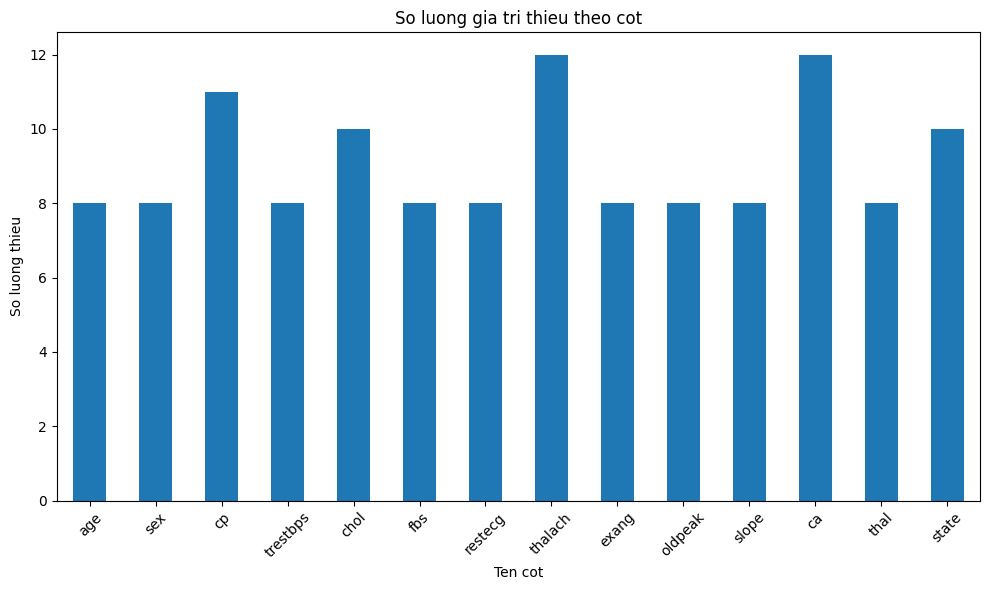

In [30]:
import matplotlib.pyplot as plt
missing_to_plot = missing_count[missing_count > 0]
if len(missing_to_plot) > 0:
    plt.figure(figsize=(10, 6))
    missing_to_plot.plot(kind='bar')
    plt.title('So luong gia tri thieu theo cot')
    plt.xlabel('Ten cot')
    plt.ylabel('So luong thieu')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [16]:
for col in df.columns:
    if df[col].isnull().sum() > 0 and df[col].dtype in ['int64', 'float64']:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"{col}: filled with median {median_val:.2f}")

age: filled with median 55.00
trestbps: filled with median 130.00
chol: filled with median 242.00
restecg: filled with median 1.00
thalach: filled with median 153.00
exang: filled with median 0.00
oldpeak: filled with median 0.70
slope: filled with median 2.00
ca: filled with median 0.00
thal: filled with median 3.00
state: filled with median 0.00


/tmp/ipykernel_5292/1489074906.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [17]:
for col in df.columns:
    if df[col].isnull().sum() > 0 and df[col].dtype not in ['int64', 'float64']:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"{col}: filled with mode {mode_val}")

sex: filled with mode M
cp: filled with mode asp
fbs: filled with mode no


/tmp/ipykernel_5292/752210499.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [18]:
print(f"Missing values left: {df.isnull().sum().sum()}")

Missing values left: 0


In [19]:
duplicates_before = df.duplicated().sum()
print(f"Duplicates: {duplicates_before}")

if duplicates_before > 0:
    df = df.drop_duplicates()
    print(f"New shape: {df.shape}")

Duplicates: 7
New shape: (296, 14)


In [21]:
def detect_and_cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    n_outliers = len(outliers)

    if n_outliers > 0:
        data[column] = data[column].clip(lower_bound, upper_bound)
        print(f"{column}: {n_outliers} outliers capped")
    else:
        print(f"{column}: no outliers")

    return data

In [23]:
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if 'target' in numeric_cols:
    numeric_cols.remove('target')
if 'num' in numeric_cols:
    numeric_cols.remove('num')

print(numeric_cols)

['age', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'state']


In [24]:
for col in numeric_cols:
    df = detect_and_cap_outliers(df, col)


if 'chol' in df.columns:
    zero_chol = (df['chol'] == 0).sum()
    if zero_chol > 0:
        median_chol = df[df['chol'] > 0]['chol'].median()
        df.loc[df['chol'] == 0, 'chol'] = median_chol
        print(f"chol: {zero_chol} zero values replaced with {median_chol:.0f}")

if 'trestbps' in df.columns:
    zero_bps = (df['trestbps'] == 0).sum()
    if zero_bps > 0:
        median_bps = df[df['trestbps'] > 0]['trestbps'].median()
        df.loc[df['trestbps'] == 0, 'trestbps'] = median_bps
        print(f"trestbps: {zero_bps} zero values replaced with {median_bps:.0f}")

age: no outliers
trestbps: 7 outliers capped
chol: 5 outliers capped
restecg: no outliers
thalach: 4 outliers capped
exang: no outliers
oldpeak: 5 outliers capped
slope: no outliers
ca: 19 outliers capped
thal: no outliers
state: no outliers


In [25]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols[:5]:
    if col in df.columns:
        print(f"{col}: {sorted(df[col].unique())}")

sex: ['F', 'M']
cp: ['aap', 'asp', 'nap', 'tap']
fbs: ['no', 'yes']


In [26]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"{col}: converted to category")

sex: converted to category
cp: converted to category
fbs: converted to category


In [27]:
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"{col}: converted to numeric")

age: converted to numeric
trestbps: converted to numeric
chol: converted to numeric
restecg: converted to numeric
thalach: converted to numeric
exang: converted to numeric
oldpeak: converted to numeric
slope: converted to numeric
ca: converted to numeric
thal: converted to numeric
state: converted to numeric


In [28]:
print(f"Final shape: {df.shape}")
print(df.isnull().sum())
print(df.info())

Final shape: (296, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
state       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       296 non-null    float64 
 1   sex       296 non-null    category
 2   cp        296 non-null    category
 3   trestbps  296 non-null    float64 
 4   chol      296 non-null    float64 
 5   fbs       296 non-null    category
 6   restecg   296 non-null    float64 
 7   thalach   296 non-null    float64 
 8   exang     296 non-null    float64 
 9   oldpeak   296 non-null    float64 
 10  slope     296 non-null    float64 
 11  ca        296 non-null    float64 
 12  thal      296 non-null    float64 
 13  state     296 non-null    float64 
dtypes: category(3), float64